# 00 · Bottom line: TabPFN as the trade filter of my live strategy

**This notebook uses my live strategy's real signals.** The features behind them are private and are not in this repo.
Each model only decides which signals to take. The file `data/strategy/bluf_predictions.parquet` holds each model's
score, its take/skip decision and the outcome, per signal.

- **Train** (Apr 15 – Jul 13): models are fitted here. Train scores are out-of-fold.
- **Test** (Jul 14 – Sep 11): used once, to calibrate each model and set its trade rule.
- **Holdout** (Sep 12 – Oct 2): everything frozen. This is exactly the period I traded live.

**Sizing:** $100 to start, and every trade stakes 15% of the current account.

Every other notebook uses generic momentum indicators instead of these features.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tabtrader import plots
plots.style()
pd.set_option("display.width", 140, "display.max_columns", 30)

In [2]:
from tabtrader import bankroll
from tabtrader.report_data import BLUF_MODELS
d = pd.read_parquet(ROOT / "data" / "strategy" / "bluf_predictions.parquet")
meta = json.loads((ROOT / "data" / "strategy" / "bluf_meta.json").read_text())
print(meta["n"]); d.head()

{'train': 2058, 'test': 938, 'holdout': 556}


,day,split,px,won,net_c_exits,net_c_hold,p__Logistic regression,take__Logistic regression,p__Random forest,take__Random forest,p__XGBoost,take__XGBoost,p__LightGBM,take__LightGBM,p__CatBoost,take__CatBoost,p__MLP,take__MLP,p__TabPFN-3.5,take__TabPFN-3.5,p__Market price,take__Market price,p__Live gate,take__Live gate,take__Every signal
0,2026-04-15,train,44.0,0,-46.0,-46.0,0.60090,True,0.66582,True,0.66303,True,0.47343,False,0.44705,True,0.76723,True,0.53943,True,0.44,False,0.13260,False,True
1,2026-04-15,train,87.0,1,12.0,12.0,0.84994,True,0.85599,True,0.83484,False,0.78339,False,0.84389,True,0.87638,False,0.84422,False,0.87,True,0.41244,False,True
2,2026-04-15,train,85.0,1,14.0,14.0,0.83813,True,0.77876,False,0.74715,False,0.70650,False,0.75739,False,0.84634,False,0.85078,True,0.85,True,0.25479,False,True
3,2026-04-15,train,95.0,1,4.0,4.0,0.95064,True,0.88284,False,0.92726,False,0.92588,False,0.90248,False,0.90018,False,0.96783,True,0.95,True,0.28829,False,True
4,2026-04-15,train,78.0,0,-27.0,-80.0,0.73380,False,0.77177,True,0.64378,False,0.63446,False,0.71570,False,0.79674,False,0.70974,False,0.78,False,0.04223,False,True


### Account value from $100, per period

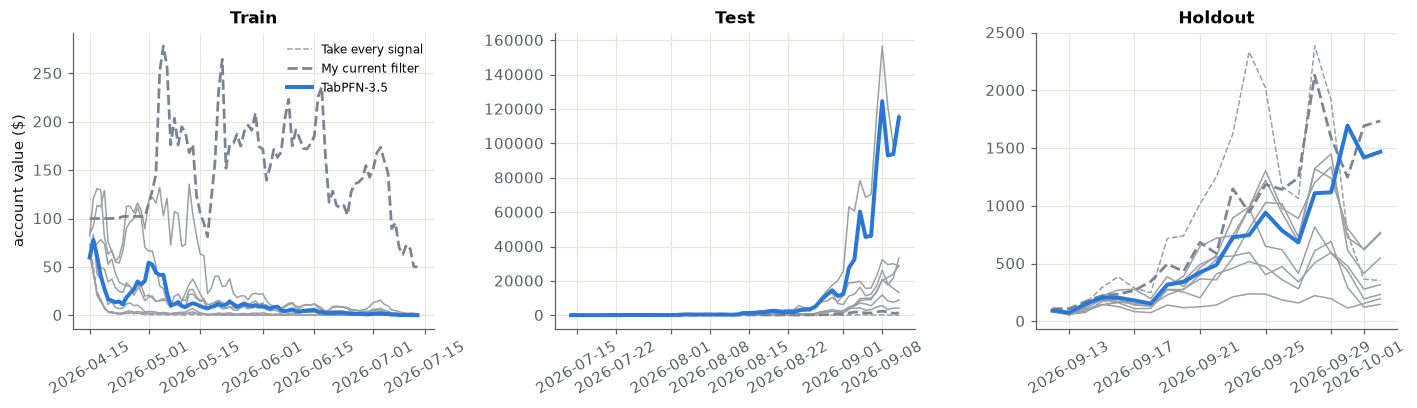

In [3]:
NAME = {"Live gate": "My current filter", "Every signal": "Take every signal"}
res = {sp: bankroll.run_models(d, BLUF_MODELS, sp) for sp in ["train", "test", "holdout"]}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, sp in zip(axes, res):
    for m in BLUF_MODELS[::-1]:
        c = pd.DataFrame(res[sp][m]["curve"], columns=["day", "v"]); c["day"] = pd.to_datetime(c["day"])
        hi = m == "TabPFN-3.5"
        ax.plot(c.day, c.v, color=plots.TABPFN if hi else ("#7a8594" if m == "Live gate" else plots.CLASSIC),
                lw=2.6 if hi else (1.8 if m == "Live gate" else 1), ls="--" if m in ("Live gate", "Every signal") else "-",
                label=NAME.get(m, m) if m in ("TabPFN-3.5", "Live gate", "Every signal") else None)
    ax.set_title(sp.capitalize()); ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("account value ($)"); axes[0].legend(fontsize=8); plt.tight_layout()

### Tear sheet

In [4]:
cols = ["final", "return_pct", "sharpe", "sortino", "max_dd_pct", "trades", "win_rate", "c_per_ct", "weeks_up"]
for sp in res:
    t = pd.DataFrame({NAME.get(m, m): {k: res[sp][m][k] for k in cols} for m in BLUF_MODELS}).T.sort_values("final", ascending=False)
    print(sp.upper()); display(t)

TRAIN


,final,return_pct,sharpe,sortino,max_dd_pct,trades,win_rate,c_per_ct,weeks_up
My current filter,49.96,-50.0,0.73,1.13,-82.0,852,0.791,0.0,7/14
XGBoost,1.43,-98.6,-0.21,-0.34,-98.6,1096,0.699,-0.09,3/14
Market price,1.01,-99.0,-1.51,-2.07,-99.2,1091,0.703,-0.54,4/14
LightGBM,0.37,-99.6,-2.22,-3.15,-99.7,722,0.662,-2.02,4/14
CatBoost,0.18,-99.8,-1.83,-2.73,-99.8,1012,0.687,-1.18,3/14
TabPFN-3.5,0.1,-99.9,-3.59,-4.51,-99.9,1031,0.71,-1.66,4/14
Logistic regression,0.03,-100.0,-2.58,-3.44,-100.0,1266,0.691,-1.37,4/14
Take every signal,0.0,-100.0,-3.11,-4.47,-100.0,2058,0.694,-1.14,3/14
Random forest,0.0,-100.0,-3.68,-5.14,-100.0,1274,0.67,-1.84,2/14
MLP,0.0,-100.0,-4.8,-5.83,-100.0,1098,0.644,-2.37,1/14


TEST


,final,return_pct,sharpe,sortino,max_dd_pct,trades,win_rate,c_per_ct,weeks_up
Random forest,116730.98,116631.0,9.11,31.58,-71.0,653,0.758,5.81,7/9
TabPFN-3.5,115014.07,114914.1,9.08,37.38,-34.8,543,0.768,6.36,8/9
CatBoost,33283.86,33183.9,7.8,28.45,-71.7,598,0.756,5.46,6/9
LightGBM,29014.95,28914.9,8.23,28.12,-77.2,430,0.742,6.76,6/9
MLP,28467.33,28367.3,8.24,29.35,-39.9,520,0.744,5.85,8/9
Logistic regression,13231.44,13131.4,7.66,20.11,-51.8,641,0.747,4.39,8/9
XGBoost,8892.43,8792.4,6.32,21.85,-82.9,600,0.743,4.68,7/9
Market price,4153.67,4053.7,6.49,16.39,-45.2,505,0.743,4.19,8/9
My current filter,1315.99,1216.0,5.43,12.55,-52.1,566,0.795,2.72,5/9
Take every signal,79.83,-20.2,2.74,7.05,-96.7,938,0.71,1.36,4/9


HOLDOUT


,final,return_pct,sharpe,sortino,max_dd_pct,trades,win_rate,c_per_ct,weeks_up
My current filter,1735.09,1635.1,10.87,38.41,-41.5,295,0.786,5.36,4/4
TabPFN-3.5,1467.37,1367.4,9.53,41.88,-27.4,314,0.72,5.05,3/4
Random forest,769.25,669.2,8.18,20.35,-53.2,392,0.709,4.45,2/4
Logistic regression,757.36,657.4,7.39,21.67,-53.2,396,0.699,3.69,3/4
XGBoost,548.47,448.5,7.36,16.78,-71.4,358,0.687,4.23,2/4
Take every signal,352.76,252.8,6.06,18.34,-85.2,556,0.683,3.08,2/4
LightGBM,316.53,216.5,5.66,13.92,-53.3,256,0.676,4.4,1/4
CatBoost,231.48,131.5,5.19,11.61,-80.2,308,0.682,3.75,2/4
Market price,195.38,95.4,4.52,9.79,-52.0,292,0.712,2.47,3/4
MLP,146.12,46.1,4.63,11.44,-82.3,380,0.674,2.89,2/4


### Weekly returns (%)

In [5]:
wk = {}
for sp in res:
    for m in ["TabPFN-3.5", "Live gate"]:
        for w, v in res[sp][m]["weekly"]:
            wk.setdefault((sp, w), {})[NAME.get(m, m)] = v
pd.DataFrame(wk).T.round(1)

TabPFN-3.5  My current filter
train   2026-04-19       -72.3                0.0
        2026-04-26       -17.5                2.1
        2026-05-03        92.3               43.2
        2026-05-10       -78.2               33.2
        2026-05-17       -26.4              -58.4
        2026-05-24        65.9              118.8
        2026-05-31       -22.4               -1.8
        2026-06-07       -51.5               16.6
        2026-06-14        18.5              -12.8
        2026-06-21       -48.0              -35.9
        2026-06-28       -53.6               24.4
        2026-07-05         7.9                4.2
        2026-07-12       -88.6              -65.8
        2026-07-19       -32.3               -0.7
test    2026-07-19       -15.7              -20.6
        2026-07-26        87.1               -8.5
        2026-08-02        32.6               14.3
        2026-08-09        88.5               97.0
        2026-08-16       277.4               15.9
        2026-08-23        29.6               -7.8
        2026-08-30       654.6              182.0
        2026-09-06       218.1              167.2
        2026-09-13       148.6               -0.0
holdout 2026-09-13       -25.1                8.2
        2026-09-20       353.8              299.8
        2026-09-27       100.7              186.9
        2026-10-04       115.0               39.8

### Zoom: the live period, with real Kalshi fills

345 live trades; TabPFN keeps 232 (kept +4.08 ¢/ct vs skipped -0.15 ¢/ct)


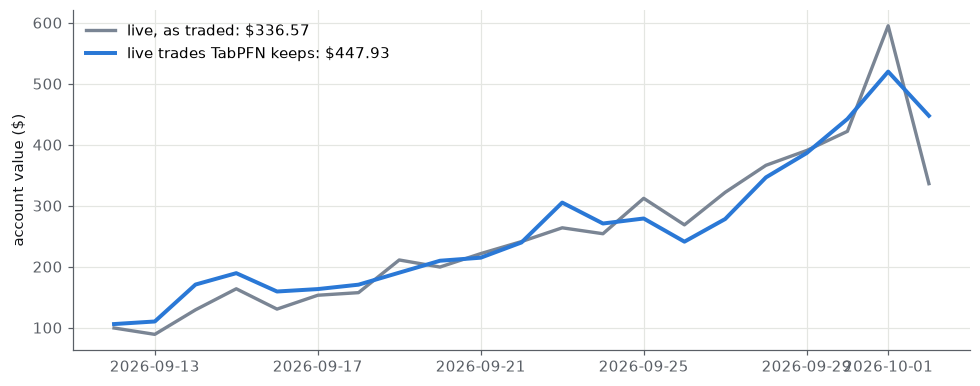

In [6]:
lt = pd.read_parquet(ROOT / "data" / "strategy" / "live_trades.parquet")
days = pd.date_range(lt.day.min(), lt.day.max(), freq="D")
fig, ax = plt.subplots(figsize=(9, 3.6))
for lab, take, col, lw in [("live, as traded", np.ones(len(lt), bool), "#7a8594", 2.2),
                           ("live trades TabPFN keeps", lt.tabpfn_keeps.values, plots.TABPFN, 2.6)]:
    eq = bankroll.daily_equity(lt.day, lt.real_net_c.values, lt.px_fill.values, take, days)
    ax.plot(eq.index, eq.values, color=col, lw=lw, label=f"{lab}: ${eq.iloc[-1]:,.2f}")
ax.set_ylabel("account value ($)"); ax.legend(); plt.tight_layout()
print(f"{len(lt)} live trades; TabPFN keeps {lt.tabpfn_keeps.sum()} "
      f"(kept {lt.real_net_c[lt.tabpfn_keeps].mean():+.2f} ¢/ct vs skipped {lt.real_net_c[~lt.tabpfn_keeps].mean():+.2f} ¢/ct)")